In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# creating dataset

np.random.seed(42)
n_samples = 100

data = {
    'Person_ID': range(1, n_samples + 1),
    'Income': np.random.randint(20, 150, n_samples),
    'Credit_Score': np.random.randint(300, 850, n_samples),
    'Age': np.random.randint(22, 65, n_samples),
    'Loan_Amount': np.random.randint(5, 100, n_samples),
    'Employment_Years': np.random.randint(0, 30, n_samples)
}

df = pd.DataFrame(data)

def approve_loan(row):
    score = 0

    if row['Income'] > 80:
        score += 3
    elif row['Income'] > 50:
        score += 2
    else:
        score += 1

    if row['Credit_Score'] > 700:
        score += 3
    elif row['Credit_Score'] > 600:
        score += 2
    else:
        score += 1

    if 30 <= row['Age'] <= 50:
        score += 2
    else: 
        score += 1
    
    if row['Loan_Amount'] < 30:
        score += 2
    elif row['Loan_Amount'] < 60:
        score += 1

    if row['Employment_Years'] > 5:
        score += 2
    elif row['Employment_Years'] > 2:
        score += 1

    score += np.random.randint(-1, 2)
    return 1 if score > 7 else 0


df['Loan_Approved'] = df.apply(approve_loan, axis=1)

df.to_csv('loan_data.csv', index=False)
print("✅ Dataset created and saved as 'loan_data.csv'")

✅ Dataset created and saved as 'loan_data.csv'


In [4]:
features = ['Income', 'Credit_Score', 'Age', 'Loan_Amount', 'Employment_Years']
X = df[features].values
y = df['Loan_Approved'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state=42
)


In [6]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.3f} = {accuracy*100:.1f}%")

cm = confusion_matrix(y_test, y_pred)

print("\n📊 Confusion Matrix:")
print("-" * 50)
print("                    Predicted")
print("              REJECTED  APPROVED")
print(f"Actual REJECTED    {cm[0][0]:3d}        {cm[0][1]:3d}")
print(f"       APPROVED    {cm[1][0]:3d}        {cm[1][1]:3d}")

print("\n💡 Understanding the results:")
print(f"  ✅ Correctly predicted REJECTED: {cm[0][0]}")
print(f"  ✅ Correctly predicted APPROVED: {cm[1][1]}")
print(f"  ❌ False Positive (Rejected but predicted Approved): {cm[0][1]}")
print(f"  ❌ False Negative (Approved but predicted Rejected): {cm[1][0]}")

# Detailed report
print("\n📋 Detailed Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, 
                          target_names=['REJECTED', 'APPROVED']))


Model Accuracy: 0.520 = 52.0%

📊 Confusion Matrix:
--------------------------------------------------
                    Predicted
              REJECTED  APPROVED
Actual REJECTED      7          3
       APPROVED      9          6

💡 Understanding the results:
  ✅ Correctly predicted REJECTED: 7
  ✅ Correctly predicted APPROVED: 6
  ❌ False Positive (Rejected but predicted Approved): 3
  ❌ False Negative (Approved but predicted Rejected): 9

📋 Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    REJECTED       0.44      0.70      0.54        10
    APPROVED       0.67      0.40      0.50        15

    accuracy                           0.52        25
   macro avg       0.55      0.55      0.52        25
weighted avg       0.57      0.52      0.52        25



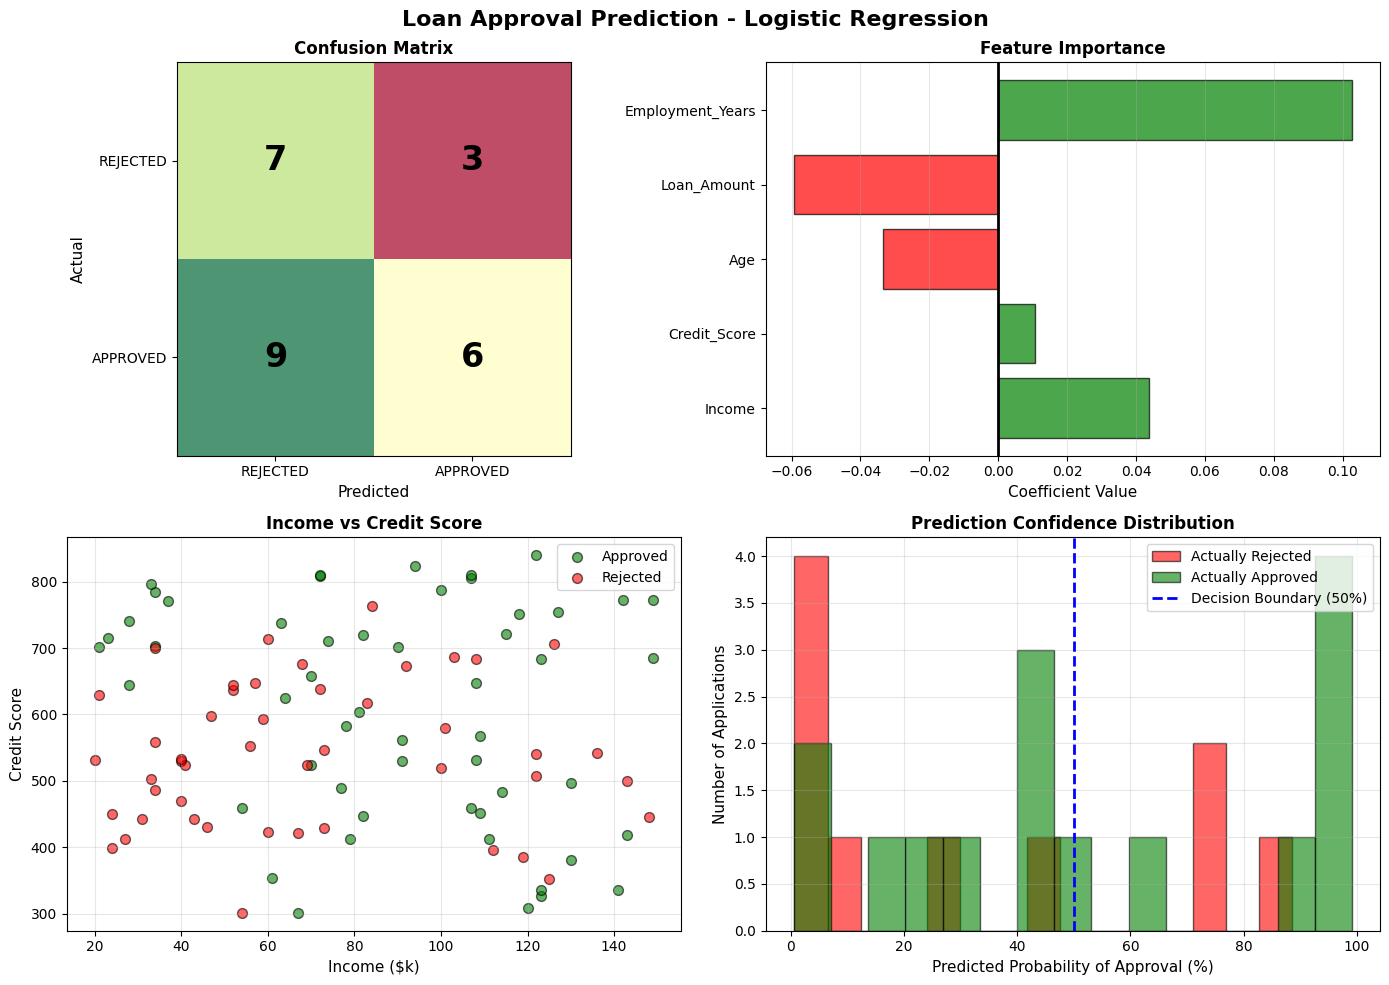

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loan Approval Prediction - Logistic Regression', 
             fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
im = ax1.imshow(cm, cmap='RdYlGn', alpha=0.7)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['REJECTED', 'APPROVED'])
ax1.set_yticklabels(['REJECTED', 'APPROVED'])
ax1.set_xlabel('Predicted', fontsize=11)
ax1.set_ylabel('Actual', fontsize=11)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, cm[i, j], ha="center", va="center",
                       color="black", fontsize=24, fontweight='bold')


ax2 = axes[0, 1]
coefficients = model.coef_[0]
colors = ['green' if c > 0 else 'red' for c in coefficients]
ax2.barh(features, coefficients, color=colors, alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='black', linewidth=2)
ax2.set_xlabel('Coefficient Value', fontsize=11)
ax2.set_title('Feature Importance', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')


ax3 = axes[1, 0]
approved_mask = df['Loan_Approved'] == 1
rejected_mask = df['Loan_Approved'] == 0

ax3.scatter(df[approved_mask]['Income'], df[approved_mask]['Credit_Score'],
           color='green', alpha=0.6, s=50, label='Approved', edgecolor='black')
ax3.scatter(df[rejected_mask]['Income'], df[rejected_mask]['Credit_Score'],
           color='red', alpha=0.6, s=50, label='Rejected', edgecolor='black')
ax3.set_xlabel('Income ($k)', fontsize=11)
ax3.set_ylabel('Credit Score', fontsize=11)
ax3.set_title('Income vs Credit Score', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
approved_proba = y_proba[y_test == 1][:, 1] * 100
rejected_proba = y_proba[y_test == 0][:, 1] * 100

ax4.hist(rejected_proba, bins=15, alpha=0.6, label='Actually Rejected', 
         color='red', edgecolor='black')
ax4.hist(approved_proba, bins=15, alpha=0.6, label='Actually Approved', 
         color='green', edgecolor='black')
ax4.axvline(x=50, color='blue', linestyle='--', linewidth=2, 
            label='Decision Boundary (50%)')
ax4.set_xlabel('Predicted Probability of Approval (%)', fontsize=11)
ax4.set_ylabel('Number of Applications', fontsize=11)
ax4.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()